# Generative Adversarial Networks (GANs) with PyTorch

## Overview

This notebook introduces **Generative Adversarial Networks (GANs)** for image generation using PyTorch. It begins by reviewing the limitations of traditional autoencoders for generative tasks and motivates the adversarial learning framework used by GANs.

The notebook implements both standard GANs and Conditional GANs (cGANs), demonstrating how a generator and discriminator are trained simultaneously to synthesize realistic handwritten digit images. It also explores adversarial optimization, latent space sampling, and conditional image generation.

## Learning Objectives

By completing this notebook, you will learn how to:

- Understand the limitations of autoencoders for image generation
- Build Generator and Discriminator networks
- Train a Generative Adversarial Network (GAN)
- Understand adversarial loss functions
- Generate realistic images from random latent vectors
- Implement Conditional GANs (cGANs)
- Generate class-conditioned images
- Visualize synthetic image generation


## From Autoencoders to GANs

Before introducing GANs, we briefly review autoencoders and discuss why reconstruction-based models often produce blurry outputs. This limitation motivates the adversarial learning framework used by Generative Adversarial Networks.

Here is the code that we wrote back in the autoencoder lecture.
The autoencoder model consists of an **encoder** that maps 
images to a vector embedding, and a **decoder** that reconstructs
images from an embedding.

In [ ]:
class Autoencoder(nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(32, 64, 7)
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 7),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

We trained an autoencoder model on the reconstruction loss: the difference in
pixel intensities between a real image and its reconstruction.

In [ ]:
def train(model, num_epochs=5, batch_size=64, learning_rate=1e-3):
    torch.manual_seed(42)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-5)
    train_loader = torch.utils.data.DataLoader(mnist_data, batch_size=batch_size, shuffle=True)
    outputs = []
    for epoch in range(num_epochs):
        for data in train_loader:
            img, label = data
            recon = model(img)
            loss = criterion(recon, img)
            loss.backward()
            optimizer.step()
            optimizer.zero_grad()

        print('Epoch:{}, Loss:{:.4f}'.format(epoch+1, float(loss)))
        outputs.append((epoch, img, recon),)
        torch.save(model.state_dict(), "autoencoder%d.pt" % epoch)
    return outputs

model = Autoencoder()
outputs = train(model, num_epochs=5)

Epoch:1, Loss:0.0098
Epoch:2, Loss:0.0059
Epoch:3, Loss:0.0044
Epoch:4, Loss:0.0035
Epoch:5, Loss:0.0030


In [ ]:
# Choose a model to load -- after 2 epochs of training
ckpt = torch.load("autoencoder1.pt")
model.load_state_dict(ckpt)

<All keys matched successfully>

Let's take a look at one MNIST image from training,
and its autoencoder reconstruction:

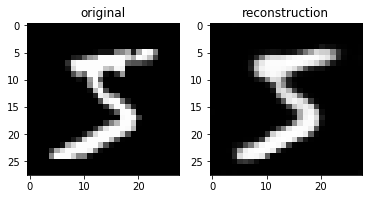

In [ ]:
original = mnist_data[0][0].unsqueeze(0)
emb = model.encoder(original)
recon_img = model.decoder(emb).detach().numpy()[0,0,:,:]

# plot the original image
plt.subplot(1,2,1)
plt.title("original")
plt.imshow(original[0][0], cmap='gray')

# plot the reconstructed
plt.subplot(1,2,2)
plt.title("reconstruction")
plt.imshow(recon_img, cmap='gray')

The reconstruction is reasonable, but notice that the reconstruction
is blurrier than
the original image. If we perturb the embedding to generate a new image, we
still should see this blurriness:

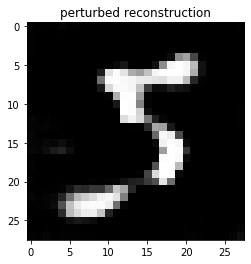

In [ ]:
# Run this a few times
x = emb + 10 * torch.randn(1, 64, 1, 1) # add a random perturbation

# reconstruct image and plot
img = model.decoder(x)[0,0,:,:]
img = img.detach().numpy()
plt.title("perturbed reconstruction")
plt.imshow(img, cmap='gray')

## Limitations of Autoencoders

Autoencoders are trained using reconstruction losses such as Mean Squared Error (MSE). While effective for representation learning, these losses encourage the network to predict average pixel values, often producing blurry reconstructions. Since the objective measures pixel-wise similarity rather than perceptual realism, generated images may appear smooth and lack fine details.

Generative Adversarial Networks address this limitation by replacing the handcrafted reconstruction objective with a learned discriminator that evaluates the realism of generated images.

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class Discriminator(nn.Module):

    def __init__(self):
        super(Discriminator, self).__init__()
        self.fc1 = nn.Linear(28*28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, 32)
        self.fc4 = nn.Linear(32, 1)
        self.dropout = nn.Dropout(0.3)
        
    def forward(self, x):
        x = x.view(-1, 28*28) # flatten image
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = self.dropout(x)
        out = self.fc4(x)
        return out

class Generator(nn.Module):

    def __init__(self):
        super(Generator, self).__init__()
        self.fc1 = nn.Linear(100, 32)
        self.fc2 = nn.Linear(32, 64)
        self.fc3 = nn.Linear(64, 128)
        self.fc4 = nn.Linear(128, 28*28)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = F.leaky_relu(self.fc1(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc2(x), 0.2)
        x = self.dropout(x)
        x = F.leaky_relu(self.fc3(x), 0.2)
        x = self.dropout(x)
        out = F.tanh(self.fc4(x))
        return out

D = Discriminator()
G = Generator()

## GAN Architecture

A Generative Adversarial Network consists of two neural networks trained simultaneously:

- **Generator (G):** Learns to transform random latent vectors into realistic synthetic images.
- **Discriminator (D):** Learns to distinguish between real images and images generated by the generator.

During training, the generator attempts to fool the discriminator, while the discriminator continuously improves its ability to detect generated samples. This adversarial process enables the generator to produce increasingly realistic images.

Let's try training the network.

In [ ]:
from torchvision import datasets
import torchvision.transforms as transforms
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.utils.data

def train(G, D, lr=0.002, batch_size=64, num_epochs=20):

    rand_size = 100;

    # optimizers for generator and discriminator
    d_optimizer = optim.Adam(D.parameters(), lr)
    g_optimizer = optim.Adam(G.parameters(), lr)
 
    # define loss function
    criterion = nn.BCEWithLogitsLoss()

    # get the training datasets
    train_data = datasets.MNIST('data', train=True, download=True, transform=transforms.ToTensor())

    # prepare data loader
    train_loader = torch.utils.data.DataLoader(train_data, batch_size=batch_size, shuffle=True)

    # keep track of loss and generated, "fake" samples
    samples = []
    losses = []

    # fixed data for testing
    sample_size=16
    test_noise = np.random.uniform(-1, 1, size=(sample_size, rand_size))
    test_noise = torch.from_numpy(test_noise).float()

    for epoch in range(num_epochs):
        D.train()
        G.train()
        
        for batch_i, (real_images, _) in enumerate(train_loader):
                    
            batch_size = real_images.size(0)
            
            # rescale images to range -1 to 1
            real_images = real_images*2 - 1
            
            # === Train the Discriminator ===
            
            d_optimizer.zero_grad()

            # discriminator losses on real images 
            D_real = D(real_images)
            labels = torch.zeros(batch_size)
            d_real_loss = criterion(D_real.squeeze(), labels)
            
            # discriminator losses on fake images
            z = np.random.uniform(-1, 1, size=(batch_size, rand_size))
            z = torch.from_numpy(z).float()
            fake_images = G(z)

            D_fake = D(fake_images)
            labels = torch.ones(batch_size) # fake labels = 1
            d_fake_loss = criterion(D_fake.squeeze(), labels)
            
            # add up losses and update parameters
            d_loss = d_real_loss + d_fake_loss
            d_loss.backward()
            d_optimizer.step()
            

            # === Train the Generator ===
            g_optimizer.zero_grad()
            
            # generator losses on fake images
            z = np.random.uniform(-1, 1, size=(batch_size, rand_size))
            z = torch.from_numpy(z).float()
            fake_images = G(z)
          
            D_fake = D(fake_images)
            labels = torch.zeros(batch_size) #flipped labels

            # compute loss and update parameters
            g_loss = criterion(D_fake.squeeze(), labels)
            g_loss.backward()
            g_optimizer.step()

        # print loss
        print('Epoch [%d/%d], d_loss: %.4f, g_loss: %.4f, ' 
              % (epoch + 1, num_epochs, d_loss.item(), g_loss.item()))

        # append discriminator loss and generator loss
        losses.append((d_loss.item(), g_loss.item()))
        
        # plot images
        G.eval()
        D.eval()
        test_images = G(test_noise)

        plt.figure(figsize=(9, 3))
        for k in range(16):
            plt.subplot(2, 8, k+1)
            plt.imshow(test_images[k,:].data.numpy().reshape(28, 28), cmap='Greys')
        plt.show()
    
    return losses

In [ ]:
losses = train(G, D, lr=0.002, batch_size=64, num_epochs=20)

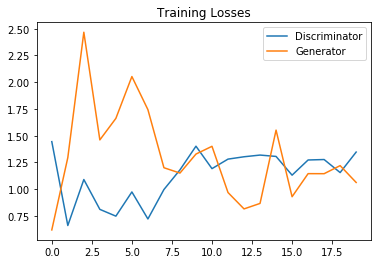

In [ ]:
fig, ax = plt.subplots()
losses = np.array(losses)
plt.plot(losses.T[0], label='Discriminator')
plt.plot(losses.T[1], label='Generator')
plt.title("Training Losses")
plt.legend()

## Training Challenges

Training GANs is significantly more challenging than training conventional supervised neural networks. Because the generator and discriminator continuously compete against one another, their losses often fluctuate throughout training rather than decreasing monotonically.

Successful GAN training typically requires careful tuning of learning rates, network architectures, and optimization strategies to maintain a balance between the two networks.

## Conditional Generative Adversarial Networks (cGANs)

Standard GANs generate images without user control over the output. Conditional GANs (cGANs) address this limitation by conditioning both the generator and discriminator on additional information, such as class labels. This enables the model to generate images belonging to a specified category while retaining the adversarial training framework.

## Example Conditional GAN

This kernel is a PyTorch implementation of Conditional GAN, which is a GAN that allows you to choose the label of the generated image. The generator and the discriminator are going to be simple feedforward networks, so I guess the images won't be as good as in this nice kernel by Sergio Gámez. I used this implementation by eriklindernoren as inspiration.

In [ ]:
%matplotlib inline
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torchvision import transforms
from torchvision import datasets

from torch.utils.data import Dataset, DataLoader
from PIL import Image
from torch import autograd
from torch.autograd import Variable
from torchvision.utils import make_grid
import matplotlib.pyplot as plt


Let's start by defining a Dataset class:

- Data Loading and Processing Tutorial on PyTorch's documentation
- torchvision has a built-in class for Fashion MNIST

In [ ]:
#load from google drive
from google.colab import drive
drive.mount('/content/gdrive')

# location on Google Drive
master_path = '/content/gdrive/My Drive/1_0 Teaching Related/MIE1517 - Deep Learning/Project 3 - GAN/cGAN_MNIST/'
#master_path = '/content/gdrive/My Drive/'


Mounted at /content/gdrive


In [ ]:
# transform = transforms.Compose([
#         transforms.ToTensor(),
#         transforms.Normalize(mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5))
# ])

transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=(0.5,), std=(0.5,))
])

# get the training datasets
dataset = datasets.MNIST('data', train=True, download=True, transform=transform)

# prepare data loader
data_loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)

Now let's define the generator and the discriminator, which are simple MLPs. I'm going to use an embedding layer for the label:

In [ ]:
class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.label_emb = nn.Embedding(10, 10)
        
        self.model = nn.Sequential(
            nn.Linear(794, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )
    
    def forward(self, x, labels):
        x = x.view(x.size(0), 784)
        c = self.label_emb(labels)
        x = torch.cat([x, c], 1)
        out = self.model(x)
        return out.squeeze()

In [ ]:
class Generator(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.label_emb = nn.Embedding(10, 10)
        
        self.model = nn.Sequential(
            nn.Linear(110, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, 784),
            nn.Tanh()
        )
    
    def forward(self, z, labels):
        z = z.view(z.size(0), 100)
        c = self.label_emb(labels)
        x = torch.cat([z, c], 1)
        out = self.model(x)
        return out.view(x.size(0), 28, 28)

In [ ]:
generator = Generator().cuda()
discriminator = Discriminator().cuda()

In [ ]:
criterion = nn.BCELoss()
d_optimizer = torch.optim.Adam(discriminator.parameters(), lr=1e-4)
g_optimizer = torch.optim.Adam(generator.parameters(), lr=1e-4)

In [ ]:
def generator_train_step(batch_size, discriminator, generator, g_optimizer, criterion):
    g_optimizer.zero_grad()
    z = Variable(torch.randn(batch_size, 100)).cuda()
    fake_labels = Variable(torch.LongTensor(np.random.randint(0, 10, batch_size))).cuda()
    fake_images = generator(z, fake_labels)
    validity = discriminator(fake_images, fake_labels)
    g_loss = criterion(validity, Variable(torch.ones(batch_size)).cuda())
    g_loss.backward()
    g_optimizer.step()
    # return g_loss.data[0]
    return g_loss.item()

In [ ]:
def discriminator_train_step(batch_size, discriminator, generator, d_optimizer, criterion, real_images, labels):
    d_optimizer.zero_grad()

    # train with real images
    real_validity = discriminator(real_images, labels)
    real_loss = criterion(real_validity, Variable(torch.ones(batch_size)).cuda())
    
    # train with fake images
    z = Variable(torch.randn(batch_size, 100)).cuda()
    fake_labels = Variable(torch.LongTensor(np.random.randint(0, 10, batch_size))).cuda()
    fake_images = generator(z, fake_labels)
    fake_validity = discriminator(fake_images, fake_labels)
    fake_loss = criterion(fake_validity, Variable(torch.zeros(batch_size)).cuda())
    
    d_loss = real_loss + fake_loss
    d_loss.backward()
    d_optimizer.step()
    # return d_loss.data[0]
    return d_loss.item()

In [ ]:
num_epochs = 30
n_critic = 5
display_step = 300
for epoch in range(num_epochs):
    print('Starting epoch {}...'.format(epoch))
    for i, (images, labels) in enumerate(data_loader):
        real_images = Variable(images).cuda()
        labels = Variable(labels).cuda()
        generator.train()
        batch_size = real_images.size(0)
        d_loss = discriminator_train_step(len(real_images), discriminator,
                                          generator, d_optimizer, criterion,
                                          real_images, labels)
        

        g_loss = generator_train_step(batch_size, discriminator, generator, g_optimizer, criterion)

    generator.eval()
    print('g_loss: {}, d_loss: {}'.format(g_loss, d_loss))
    z = Variable(torch.randn(9, 100)).cuda()
    labels = Variable(torch.LongTensor(np.arange(9))).cuda()
    sample_images = generator(z, labels).unsqueeze(1).data.cpu()
    grid = make_grid(sample_images, nrow=3, normalize=True).permute(1,2,0).numpy()
    plt.imshow(grid)
    plt.show()

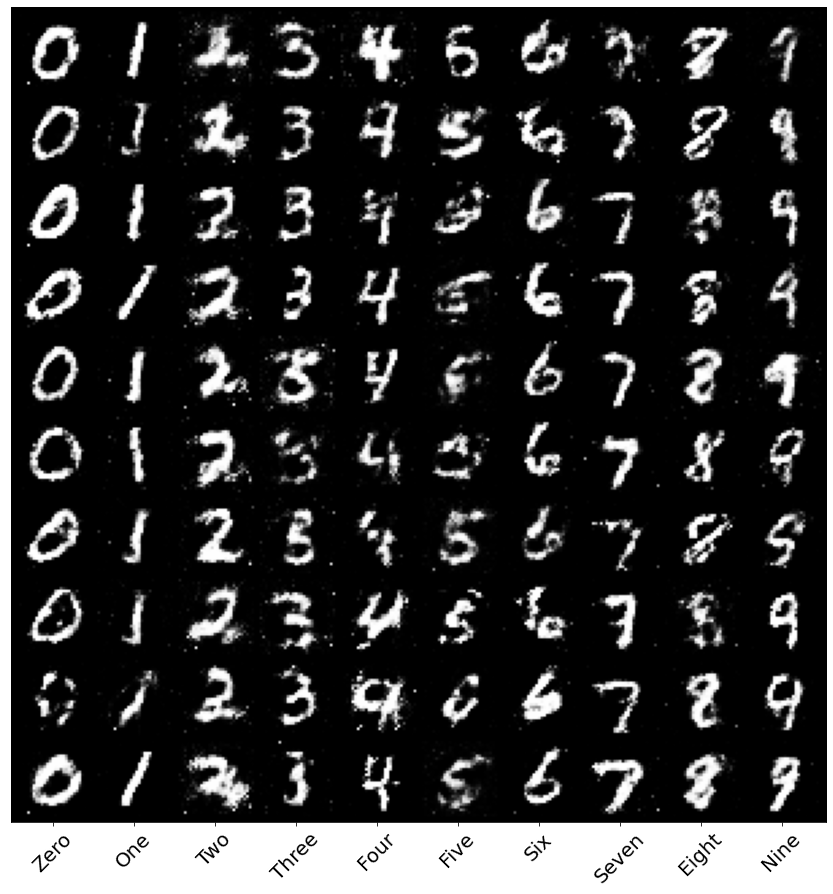

In [ ]:
z = Variable(torch.randn(100, 100)).cuda()
labels = Variable(torch.LongTensor([i for _ in range(10) for i in range(10)])).cuda()
sample_images = generator(z, labels).unsqueeze(1).data.cpu()
grid = make_grid(sample_images, nrow=10, normalize=True).permute(1,2,0).numpy()
fig, ax = plt.subplots(figsize=(15,15))
ax.imshow(grid)
_ = plt.yticks([])
_ = plt.xticks(np.arange(15, 300, 30), ['Zero', 'One', 'Two', 'Three', 'Four', 'Five', 'Six', 'Seven', 'Eight', 'Nine'], rotation=45, fontsize=20)

# Results

## Summary

This notebook implemented Generative Adversarial Networks for image synthesis using the MNIST dataset.

### Implemented Models

- Fully Connected GAN
- Conditional GAN (cGAN)

### Key Outcomes

- Learned to generate realistic handwritten digit images from random latent vectors.
- Demonstrated adversarial training between generator and discriminator networks.
- Explored conditional image generation using class labels.
- Compared GAN-based image generation with autoencoder reconstruction.
- Highlighted common GAN training challenges, including instability and hyperparameter sensitivity.

These experiments demonstrate how adversarial learning enables neural networks to generate realistic synthetic images and forms the foundation for many modern generative AI models.

# Conclusion

Generative Adversarial Networks provide a powerful framework for learning complex data distributions through adversarial optimization. Unlike reconstruction-based autoencoders, GANs learn to generate visually realistic samples by competing against a discriminator network. This notebook introduced both standard GANs and Conditional GANs, illustrating how adversarial learning enables controllable, high-quality image generation and serves as a foundation for modern generative AI techniques.